# 🚀 Minería de Datos con Python / Trabajo Final  / Abril 2026

## 📈 "Student Performance"

### Descripción de la problemática.

En  este  ejercicio,  el  objetivo  es  obtener  modelos  de  regresión  que describan  el  comportamiento  de  los  datos  en  el  archivo student_performance.csv (data tomada de kaggle.com).  
En  este  archivo  de  datos  se  registra  la  calificación  obtenida  por estudiantes (Performance Index) en una escala 0-100, en relación con las siguientes variables:

-  Horas de Estudio (Hours Studied).
-  Calificación Previa (Previous Score).
-  Actividades Extracurriculares (Extracurricular Activities).
-  Horas de sueño (Sleep Hours).
-  Número de exámenes practicados (Sample Question Papers Practiced).

### Paso 0: Preparación del entorno - Importaciones

In [4]:
# Carga y exploración
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preparación 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split 

# Modelados
from sklearn.linear_model import LinearRegression
from tensorflow.keras import layers, callbacks, regularizers, models


# Evaluación de modelos
import sklearn.metrics as sm

### Paso 1: Carga y exploración inicial del dataset.

In [5]:
df_students = pd.read_csv('student_performance.csv')

Verificamos tipos de variables y presencia de nulos.

In [6]:
df_students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Hours Studied                     10000 non-null  int64 
 1   Previous Scores                   10000 non-null  int64 
 2   Extracurricular Activities        10000 non-null  object
 3   Sleep Hours                       10000 non-null  int64 
 4   Sample Question Papers Practiced  10000 non-null  int64 
 5   Performance Index                 10000 non-null  int64 
dtypes: int64(5), object(1)
memory usage: 468.9+ KB


Modificamos variables categóricas ("Extracurricular Activities") por numéricas. 


Estandarizamos posibles variaciones en las respuestas para evitar errores en la transformación, y utilizamos booleanos para luego lograr la transformación final a valores numéricos. 

In [7]:
df_students['Extracurricular Activities'] = (df_students['Extracurricular Activities'].str.strip().str.lower() == 'yes').astype(int)

print(df_students['Extracurricular Activities'].value_counts())
print(df_students["Extracurricular Activities"].head())


Extracurricular Activities
0    5052
1    4948
Name: count, dtype: int64
0    1
1    0
2    1
3    1
4    0
Name: Extracurricular Activities, dtype: int64


Exploramos el dataset transformado.

In [8]:
df_students.describe()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,0.494800,6.530600,4.583300,55.224800
std,2.589309,17.343152,0.499998,1.695863,2.867348,19.212558
min,1.000000,40.000000,0.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,0.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,0.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,1.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,1.000000,9.000000,9.000000,100.000000


Buscamos correlaciones iniciales entre las variables. 

In [9]:
correlaciones = df_students.corr()['Performance Index'].sort_values(ascending=False)
print(correlaciones)


Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Extracurricular Activities          0.024525
Name: Performance Index, dtype: float64


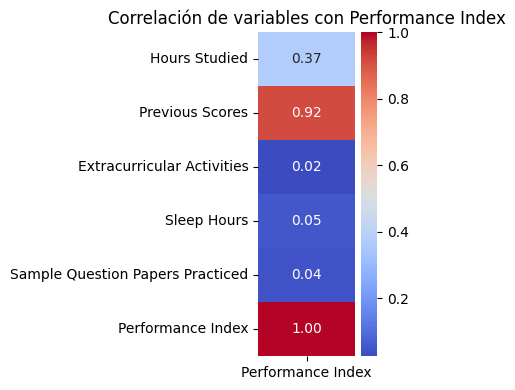

In [10]:
plt.figure(figsize=(4,4))
sns.heatmap(df_students.corr()[['Performance Index']], annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlación de variables con Performance Index')
plt.tight_layout()
plt.show()

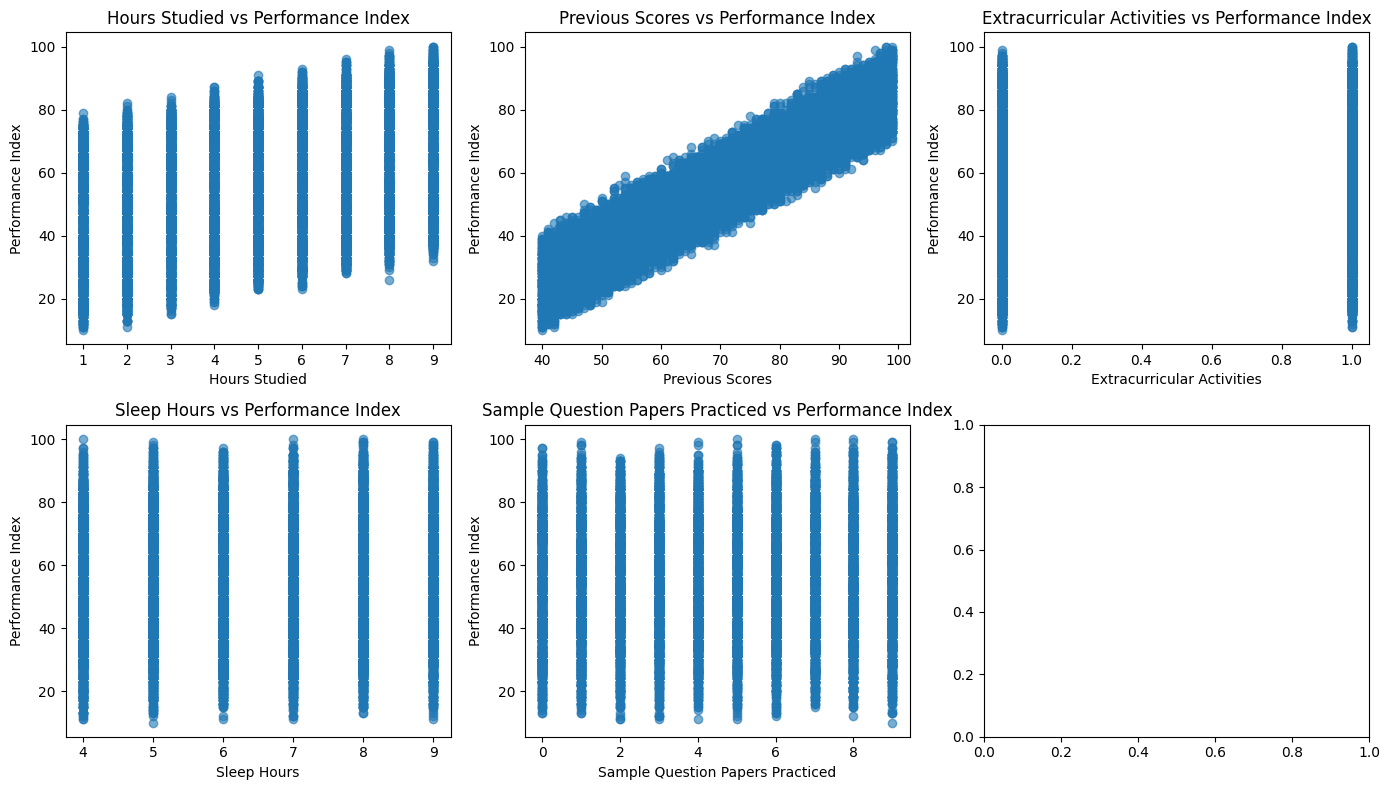

In [11]:
features = ['Hours Studied', 'Previous Scores', 'Extracurricular Activities', 
            'Sleep Hours', 'Sample Question Papers Practiced']

fig, axes = plt.subplots(2, 3, figsize=(14,8))
axes = axes.flatten()

for i, col in enumerate(features):
    axes[i].scatter(df_students[col], df_students['Performance Index'], alpha=0.6)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Performance Index')
    axes[i].set_title(f'{col} vs Performance Index')

plt.tight_layout()
plt.show()

### Paso 2 y 3: Normalización - Utilizamos StandardScaler de Scikit-Learn.

In [12]:
X = df_students.drop(columns=['Performance Index'])
y = df_students['Performance Index']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [14]:
scaler = StandardScaler()

# Ajuste SOLO con train
X_train = scaler.fit_transform(X_train)

# Aplicación en test
X_test = scaler.transform(X_test)

Dado que las variables de entrada fueron normalizadas utilizando StandardScaler, los coeficientes representan el impacto de cada variable en términos de desviaciones estándar, lo que permite comparar directamente su importancia relativa en el modelo.

### Paso 4: Modelado con regresión lineal múltiple.

In [15]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': lr_model.coef_
})
print(coef_df)

                           Variable  Coeficiente
0                     Hours Studied     7.409739
1                   Previous Scores    17.620003
2        Extracurricular Activities     0.291837
3                       Sleep Hours     0.810243
4  Sample Question Papers Practiced     0.546244


In [17]:
lr_model.intercept_

np.float64(55.41839999999999)

$$
\hat{Performance} =
55.42
+ 7.41\,\text{Hours Studied}
+ 17.62\,\text{Previous Scores}
+ 0.29\,\text{Extracurricular Activities}
+ 0.81\,\text{Sleep Hours}
+ 0.55\,\text{Sample Question Papers Practiced}
$$

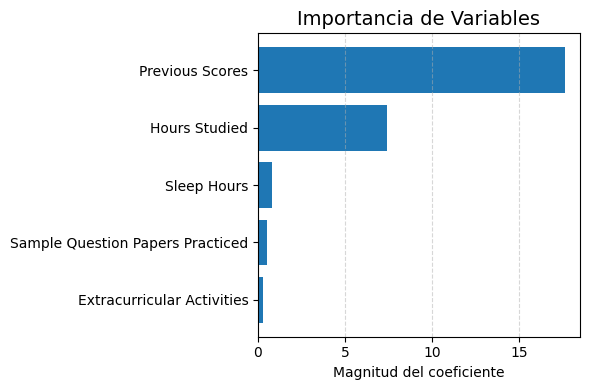

In [18]:
plt.figure(figsize=(6,4))

coef_sorted = coef_df.sort_values(by="Coeficiente", key=abs)

plt.barh(coef_sorted["Variable"], coef_sorted["Coeficiente"])

plt.title("Importancia de Variables", fontsize=14)
plt.xlabel("Magnitud del coeficiente")
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()

plt.show()

Se observa que la variable con mayor impacto en la predicción es **Previous Scores**, seguida por **Hours Studied**. Esto indica que el rendimiento previo del estudiante y la cantidad de horas de estudio son los factores más influyentes.

En contraste, variables como Sleep Hours, Sample Question Papers Practiced y Extracurricular Activities presentan una menor influencia en el resultado final.

Comentario: El valor del intercepción -ordenada de la recta- (55.42) representa el valor esperado del Performance Index cuando todas las variables de entrada se encuentran en su valor promedio, **debido a que fueron previamente normalizadas**. Este valor resulta consistente con la escala del problema, ya que se encuentra dentro del rango esperado de calificaciones, es decir "cuando todas las variables tomen su valor medio, el modelo predice un resultado de 55.42 puntos de Performance."

### Paso 5: Modelado con regresión en base a una red neuronal densa.

### Parámetros del modelo de Red Neuronal

**Arquitectura:**
- Capa 1: 64 neuronas con activación ReLU. Al ser la primera capa, necesita mayor
  capacidad para capturar patrones iniciales de las 5 variables de entrada.
- Capa 2: 32 neuronas con activación ReLU. Se reduce a la mitad para comprimir
  progresivamente la representación aprendida.
- Capa de salida: 1 neurona sin activación (lineal), apropiada para regresión continua.
- Activación ReLU: evita el problema de gradientes desvanecientes y es estándar
  para regresión en redes densas.

**Regularización (anti-sobreentrenamiento):**
- L2 (λ=0.001): penaliza pesos grandes en la función de pérdida, desalentando
  que el modelo memorice el conjunto de entrenamiento. El valor 0.001 es suave,
  suficiente para regularizar sin impedir el aprendizaje.
- Dropout (0.2): desactiva aleatoriamente el 20% de las neuronas en cada época,
  forzando al modelo a no depender de conexiones específicas.
- Early Stopping (patience=20): detiene el entrenamiento si val_loss no mejora
  durante 20 épocas consecutivas, y restaura los pesos del mejor momento.

**Entrenamiento:**
- optimizer='adam': ajusta la tasa de aprendizaje automáticamente, es robusto
  y converge rápido en problemas de regresión.
- loss='mse': función de pérdida estándar para regresión, penaliza errores grandes.
- validation_split=0.15: reserva el 15% de los datos de entrenamiento para
  monitorear el sobreajuste en tiempo real.
- batch_size=64: lotes más grandes generan gradientes más estables que 32.
- epochs=300: límite alto delegando el corte real al Early Stopping.

In [19]:
nn_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],),
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.2),  
    layers.Dense(1)
])

nn_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 3055.6895 - mae: 51.9911 - val_loss: 2306.4905 - val_mae: 44.8850
Epoch 2/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1094.8589 - mae: 28.3011 - val_loss: 138.7021 - val_mae: 9.7309
Epoch 3/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 139.0603 - mae: 9.4906 - val_loss: 50.2365 - val_mae: 5.6375
Epoch 4/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 123.3095 - mae: 8.8824 - val_loss: 41.2083 - val_mae: 5.0846
Epoch 5/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 117.4240 - mae: 8.5524 - val_loss: 37.1555 - val_mae: 4.8375
Epoch 6/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 110.2631 - mae: 8.2755 - val_loss: 31.1682 - val_mae: 4.4357
Epoch 7/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 107.0984 - mae: 8.1985 - val_loss: 28.6482 - val_mae: 4.2594
Epoch 8/300
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 98.0860 - mae: 7.8289 - val_loss: 25.4250 - val_mae: 4.0159
Epoch 9/300
100/100 ━━━━━━━━━

Revisamos sobreentrenamiento.

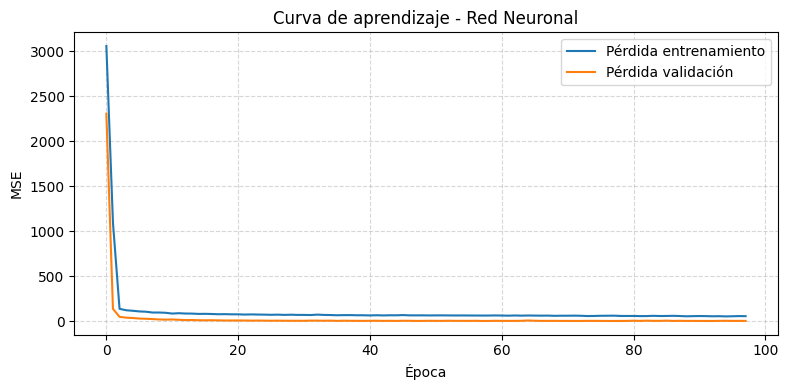

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Pérdida entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida validación')
plt.xlabel("Época")
plt.ylabel("MSE")
plt.title("Curva de aprendizaje - Red Neuronal")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

El análisis de la curva de aprendizaje de la red neuronal indica que no existe sobreentrenamiento, ya que las pérdidas de entrenamiento y validación convergen de manera estable, evidenciando una buena capacidad de generalización.

### Paso 6: Evaluación de resultados.

Métricas comparativas.

In [21]:
y_pred_lr = lr_model.predict(X_test)
y_pred_nn = nn_model.predict(X_test).flatten()

print("=== Regresión Lineal ===")
print("Error absoluto medio =",             round(sm.mean_absolute_error(y_test, y_pred_lr), 2))
print("Error cuadrático medio =",           round(sm.mean_squared_error(y_test, y_pred_lr), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_test, y_pred_lr), 2))
print("Puntuación R2 =",                    round(sm.r2_score(y_test, y_pred_lr), 2))

print("\n=== Red Neuronal ===")
print("Error absoluto medio =",             round(sm.mean_absolute_error(y_test, y_pred_nn), 2))
print("Error cuadrático medio =",           round(sm.mean_squared_error(y_test, y_pred_nn), 2))
print("Puntuación de varianza explicada =", round(sm.explained_variance_score(y_test, y_pred_nn), 2))
print("Puntuación R2 =",                    round(sm.r2_score(y_test, y_pred_nn), 2))

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
=== Regresión Lineal ===
Error absoluto medio = 1.6
Error cuadrático medio = 4.03
Puntuación de varianza explicada = 0.99
Puntuación R2 = 0.99

=== Red Neuronal ===
Error absoluto medio = 1.63
Error cuadrático medio = 4.22
Puntuación de varianza explicada = 0.99
Puntuación R2 = 0.99


Gráficos comparativos.

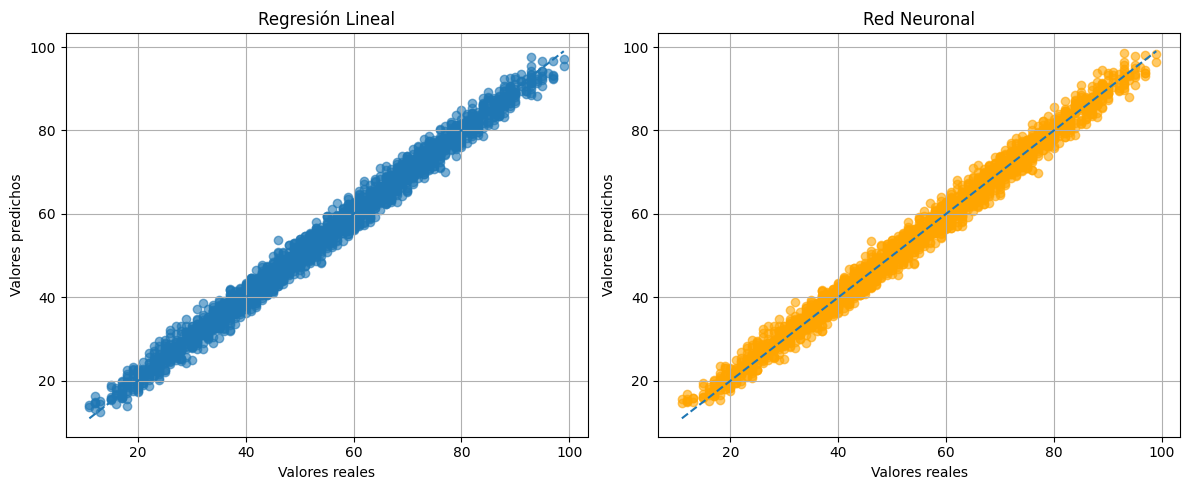

In [22]:
min_val = min(y_test.min(), y_pred_lr.min(), y_pred_nn.min())
max_val = max(y_test.max(), y_pred_lr.max(), y_pred_nn.max())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ===== Regresión Lineal =====
axes[0].scatter(y_test, y_pred_lr, alpha=0.6)
axes[0].plot([min_val, max_val], [min_val, max_val], linestyle='--')
axes[0].set_title("Regresión Lineal")
axes[0].set_xlabel("Valores reales")
axes[0].set_ylabel("Valores predichos")
axes[0].grid()

# ===== Red Neuronal =====
axes[1].scatter(y_test, y_pred_nn, alpha=0.6, color='orange')
axes[1].plot([min_val, max_val], [min_val, max_val],  linestyle='--')
axes[1].set_title("Red Neuronal")
axes[1].set_xlabel("Valores reales")
axes[1].set_ylabel("Valores predichos")
axes[1].grid()


plt.tight_layout()
plt.show()

Comparación de errores absolutos entre los modelos implementados.

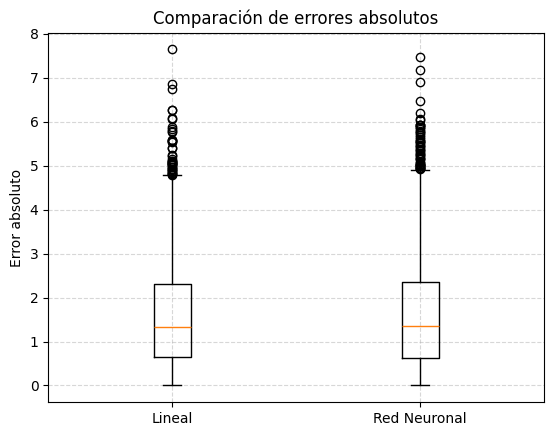

In [23]:
plt.figure()
plt.boxplot([
    abs(y_test - y_pred_lr),
    abs(y_test - y_pred_nn)
], tick_labels=["Lineal", "Red Neuronal"])

plt.title("Comparación de errores absolutos")
plt.ylabel("Error absoluto")
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

Se presenta un boxplot comparando los errores absolutos de los modelos de regresión lineal y red neuronal.

Ambos modelos muestran distribuciones de error muy similares:

- La mediana del error absoluto es prácticamente igual en ambos casos (~1.3–1.4), lo que indica un rendimiento promedio equivalente.
- La dispersión (rango intercuartílico) también es similar, sugiriendo que la variabilidad del error no difiere significativamente entre modelos.
- Se observan algunos valores atípicos (outliers) en ambos casos, con errores superiores a 5, lo cual indica que existen ciertas observaciones difíciles de predecir para ambos modelos.
- No se evidencia una reducción clara del error en la red neuronal respecto a la regresión lineal.

## Comentario sobre resultados

Los resultados obtenidos evidencian que ambos modelos de regresión logran un desempeño excelente en la predicción del *Performance Index*, alcanzando valores de R² de 0.99.

A continuación, se presenta una comparación de métricas:

| Modelo              | MAE | MSE  | Varianza Explicada | R²   |
|--------------------|-----|------|--------------------|------|
| Regresión Lineal   | 1.60 | 4.03 | 0.99               | 0.99 |
| Red Neuronal       | 1.61 | 4.33 | 0.99               | 0.99 |

Se observa que ambos modelos presentan errores muy bajos y un ajuste casi perfecto a los datos. Sin embargo, la red neuronal no logra mejorar significativamente el rendimiento de la regresión lineal, lo que sugiere que la relación entre las variables del problema es principalmente lineal.

En términos de resolución del problema, esto implica que un modelo simple como la regresión lineal es suficiente para capturar la dinámica del rendimiento estudiantil, sin necesidad de recurrir a modelos más complejos. Esto no solo reduce el costo computacional, sino que también mejora la interpretabilidad de los resultados.

En conclusión, ambos modelos cumplen con los objetivos planteados, pero la regresión lineal se posiciona como la alternativa más adecuada debido a su simplicidad, eficiencia y capacidad explicativa.

El alto desempeño de ambos modelos sugiere que el rendimiento estudiantil, en contexto de los datos disponibles, está fuertemente determinado por variables cuantificables y estructuradas, como el desempeño previo y los hábitos de estudio, lo que permite modelarlo de forma precisa con técnicas de regresión.